In [19]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd())) 
from typing import Literal 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
DATA_DIR = '../data/'
stage2_dir = os.path.join(DATA_DIR, 'stage2_netrating')


In [3]:
date = '20241022'
stage2_output = os.path.join(stage2_dir, f'df_test_stage2_effort_{date}.csv')
stage2_train = os.path.join(stage2_dir, f'df_train_stage2_effort_{date}.csv')
df = pd.read_csv(stage2_output)
df_train = pd.read_csv(stage2_train)

In [4]:
df.rename(columns={'y_pred_test':'pred_nrtg'}, inplace=True)
df

,SEASON_ID,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,HOME_AVG10_NET_COMPOSITE_EFFORT,AWAY_AVG10_NET_COMPOSITE_EFFORT,AVG10_EFG_PCT_DIFF,AVG10_FTA_RATE_DIFF,AVG10_TM_TOV_PCT_DIFF,AVG10_OREB_PCT_DIFF,AVG10_NET_COMPOSITE_EFFORT_DIFF,pred_nrtg
0,22024,22400061,2024-10-22,1610612738,1610612752,BOS,NYK,16.950916,18.171884,0.0222,-0.0866,-0.0121,-0.0438,-1.220968,3.272845
1,22024,22400062,2024-10-22,1610612747,1610612750,LAL,MIN,15.577461,16.836173,0.0177,-0.0182,0.0120,-0.0067,-1.258712,2.149552


In [5]:
df_train.head()

,SEASON_ID,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,HOME_AVG10_NET_COMPOSITE_EFFORT,AWAY_AVG10_NET_COMPOSITE_EFFORT,AVG10_EFG_PCT_DIFF,AVG10_FTA_RATE_DIFF,AVG10_TM_TOV_PCT_DIFF,AVG10_OREB_PCT_DIFF,AVG10_NET_COMPOSITE_EFFORT_DIFF,y_pred_train
0,22022,22200001,2022-10-18,1610612738,1610612755,BOS,PHI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
1,22022,22200002,2022-10-18,1610612744,1610612747,GSW,LAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
2,22022,22200003,2022-10-19,1610612765,1610612753,DET,ORL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
3,22022,22200004,2022-10-19,1610612754,1610612764,IND,WAS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
4,22022,22200005,2022-10-19,1610612737,1610612745,ATL,HOU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131


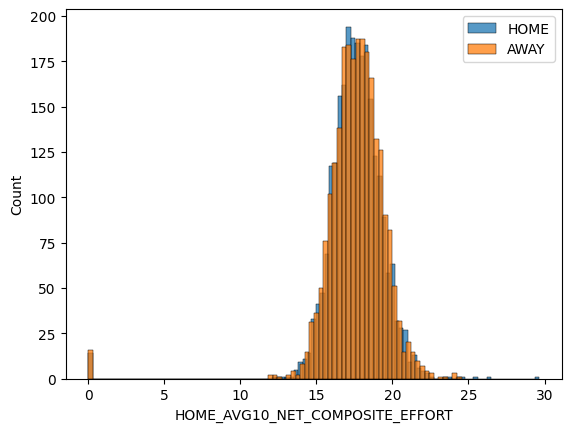

In [6]:
sns.histplot(df_train['HOME_AVG10_NET_COMPOSITE_EFFORT'], label='HOME')
sns.histplot(df_train['AWAY_AVG10_NET_COMPOSITE_EFFORT'], label='AWAY')
plt.legend(loc='best')

In [7]:
df_train['HOME_AVG10_NET_COMPOSITE_EFFORT'].describe()

count    2460.000000
mean       17.591615
std         2.033071
min         0.000000
25%        16.664988
50%        17.654346
75%        18.622179
max        29.643219
Name: HOME_AVG10_NET_COMPOSITE_EFFORT, dtype: float64

In [8]:
df_train['AWAY_AVG10_NET_COMPOSITE_EFFORT'].describe()

count    2460.000000
mean       17.622596
std         2.107649
min         0.000000
25%        16.678343
50%        17.696368
75%        18.748264
max        24.542279
Name: AWAY_AVG10_NET_COMPOSITE_EFFORT, dtype: float64

<Axes: xlabel='y_pred_train', ylabel='Count'>

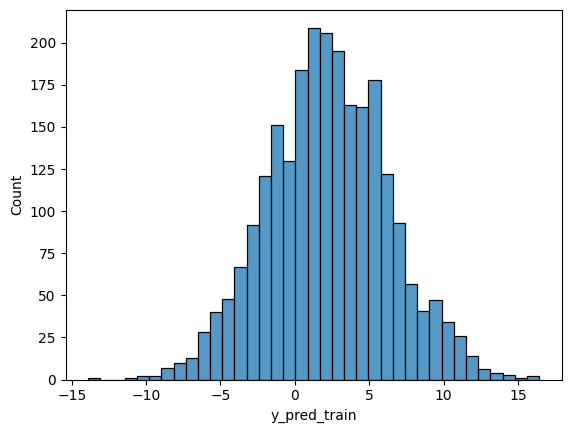

In [9]:
sns.histplot(df_train['y_pred_train'])

In [10]:
df_train['y_pred_train'].describe()

count    2460.000000
mean        2.220209
std         4.104116
min       -13.889701
25%        -0.549817
50%         2.219746
75%         5.014705
max        16.423537
Name: y_pred_train, dtype: float64

## Effort Interpretations
1. $\text{Offensive Effort} = 0.15 X_{OFF\_BOXOUTS} + 0.63X_{SCREEN\_AST} - 0.12X_{OFF\_LOOSE\_BALLS\_RECOVERED}$
2. $\text{Defensive Effort} = -0.35X_{DEFLECTIONS}+0.09X_{CONTESTED\_3PT}-0.22X_{CONTESTED\_2PT}-0.69X_{DEF\_LOOSE\_BALLS\_RECOVERED}-0.84X_{CHARGES\_DRAWN}-0.43X_{DEF\_BOXOUTS}$

Both of the offensive and defensive effort metrics are in terms of points scored per 100 possessions (above zero offensive effort) and points allowed per 100 possessions (below zero defensive effort), respectively.

- Example 1 - If all offensive hustle metrics had value of 10 --> $\text{Offensive Effort} = 6.6$. This means with this many offensive effort plays, we'd expect the team to score 6.6 points per 100 possessions more.

- Example 2 - If all defensive hustle metrics had value of 10 --> $\text{Defensive Effort} = -24.4$. This means with this many defensive effort plays, we'd expect the team to prevent 24.4 points per 100 possessions more (from the the opposing team).


3. $\text{Net Effort} = 0.59X_{OFF\_EFFORT}-1.05X_{DEF\_EFFORT}$

This metric is in terms of $\bigg[\frac{PTS Scored}{100 POSS} - \frac{PTS Allowed}{100 POSS}\bigg]$, which we might think of as net points scored per 100 possessions compared to a team with zero offensive and defensive effort. 

- Example 3 - Since offensive effort values contribute positively and defensive effort values contribute negatively, suppose $X_{OFF\_EFFORT}=10$ and $X_{DEF\_EFFORT}=-10$ --> $\text{Net Effort} = 16.4$. This means that with the defensive and offensive effort plays that make up 10 more points scored and 10 fewer points allowed per 100 possessions, the team we'd expect the team to have a 16.4 points per 100 possessions advantage over the opponent.

Some other metric information that could be useful:
- $X_{OFF\_EFFORT} \in [-1, 16]$
- $X_{DEF\_EFFORT} \in [-4,-28]$
- $X_{NET\_EFFORT} \in [5, 34]$

In [9]:
2880/200

14.4

# Euler Maruyama
- 48 Minutes = 2,880 Seconds
- We will use $T=2,880$ as the final time
- We need to partition the interval $[0,T]$ into sub-intervals of length $\Delta t = \frac{T}{N}$
- Each game has roughly 200 possessions (100 from both teams). We can then estimate the amount of time per possession.
$$\frac{2,880}{200}\bigg[\frac{Seconds}{Possessions}\bigg] = 14.4 \frac{Seconds}{Possession}$$
- As a result, one option is to divide up our interval $[0,T]$ into sub-intervals of 14.4 seconds in length, and therefore making $N=200$.
$$X_{t+1} = X_{t} + \text{drift}\cdot \Delta t + \text{diffusion} \cdot \Delta W$$

Note that our optimal `pred_nrtg` is in terms of points per 100 possessions. Therefore, we'll need to multiply this by a scaling factor to obtain the correct units. 
$$\frac{x}{100}\bigg[\frac{Points}{Possessions}\bigg] \times \frac{1}{14.4}\bigg[\frac{Possessions}{Seconds}\bigg] \times \frac{s}{1}\bigg[\frac{Seconds}{\Delta t}\bigg]$$

In other words, 
1. Take points per 100 possessions
2. Divide by 100 to get points per possession
3. Since there are 14.4 seconds per possession, this is also the number of points per 14.4 seconds.
4. (Optional): If we want more granular intervals, divide by 14.4 seconds to get points per second.
5. (Optional): If we have points per second, multiply by the number of seconds per interval. 

In [47]:
class SingleGameSim:
    """
    The class enables the simulation, prediction, and evaluation of a single game outcome. 

    Note: While we could take special care to ensure correct scaling, we will most likely
    just use T = 1, as is done in Stern (1994), who models the score differential process
    as a Brownian motion on the time interval [0,1]. 
    """
    def __init__(
        self,
        hbar: float, 
        abar: float,
        pred_nrtg: float,
        N_sim: int = 100,
        T: float = 1, 
        dt: float = None, 
        N: int = None, 
        m_H: float = 1, # Need to estimate with additional linear model
        m_A: float = 1, # Need to estimate with additional linear model
        alpha_H: float = 10, # Need to choose based on risk tolerance
        alpha_A: float = 10, # Need to choose based on risk tolerance
        sigma: float = 15 # Need to estimate with additional linear model
    ) -> None:
        self.T = T
        self.N = N
        self.dt = dt
        self.hbar = hbar # Home average effort
        self.abar = abar # Away average effort
        self.m_H = m_H # Home scale factor
        self.m_A = m_A # Away scale factor
        self.alpha_H = alpha_H # Home risk factor
        self.alpha_A = alpha_A # Away risk factor
        self.scaled_hbar = self.hbar/self.T
        self.scaled_abar = self.abar/self.T
        self.pred_nrtg = pred_nrtg
        self.scaled_pred_nrtg = self.pred_nrtg/self.T
        self.X0 = 0
        self.sigma = sigma
        self.X_mat = None
        self.N_sim = N_sim
        

        if self.N:
            self.dt = self.T/self.N
        if self.dt:
            self.N = int(self.T/self.dt)

        self.time_vec = np.linspace(0,self.T,self.N+1)
        if self.T == 1:
            time_scale = 'Proportion of Game Played'
        elif self.T == 2880:
            time_scale = 'Seconds'
        elif self.T == 48:
            time_scale = 'Minutes'
        else:
            raise ValueError('Unsupported time scale. Please set T equal to 1, 2880, or 48.')

            
        print("="*100)
        print("Time Interval Information")
        print("="*100)
        print(f"Time Scale: {time_scale}")
        print(f"Total Time Interval: [0,{self.T}]")
        print(f"Sub-interval length: Δt = {self.dt}")
        print(f"Number of sub-intervals: {self.N}")
        print(f"Number of time points: {len(self.time_vec)}")
        print("\n")
        print("="*100)
        print("Team Information")
        print("="*100)
        print(f"Home Avg Effort: {self.scaled_hbar: .3f}, Away Avg Effort: {self.scaled_abar: .3f}")
        print(f"Home Scaling Factor: {self.m_H}, Away Scaling Factor: {self.m_A}")
        print(f"Home Risk: {self.alpha_H}, Away Risk: {self.alpha_A}")
        print(f"Predicted Drift w/o Additional Effort: {self.scaled_pred_nrtg: .3f}")

    @staticmethod
    def optimal_control(avg_effort: float, scale_factor: float, risk_factor: float, team: Literal["home","away"]):
        if team == "home":
            return avg_effort + .5 * scale_factor / risk_factor
        elif team == "away":
            return avg_effort - .5 * scale_factor / risk_factor
        else:
            raise ValueError("team must be either 'home' or 'away'")

    
    def value_function(self, t: float, x: float, team: Literal["home", "away"]):
        if team == "home":
            return x + (.25 * self.m_H**2 / self.alpha_H + self.scaled_pred_nrtg + self.m_H * self.scaled_hbar - self.m_A * self.scaled_abar - .5 * self.m_A**2 / self.alpha_A) * (self.T - t)
        elif team == "away":
            return -x + (.25 * self.m_A**2 / self.alpha_A - (self.scaled_pred_nrtg + self.m_H * self.scaled_hbar - self.m_A * self.scaled_abar) - .5 * self.m_H**2 / self.alpha_H) * (self.T - t)
        else: 
            raise ValueError("team must be either 'home' or 'away'")

    @property
    def home_optimal_control(self):
        return self.optimal_control(avg_effort=self.scaled_hbar, scale_factor=self.m_H, risk_factor=self.alpha_H, team="home")

    @property
    def away_optimal_control(self):
        return self.optimal_control(avg_effort=self.scaled_abar, scale_factor=self.m_A, risk_factor=self.alpha_A, team="away")

    @property
    def home_value_t0(self):
        return self.value_function(t=0, x=0, team="home")

    @property
    def away_value_t0(self):
        return self.value_function(t=0, x=0, team="away")


    def sde_drift(self):
        # Compute optimal controls
        h_opt_control = self.optimal_control(avg_effort=self.scaled_hbar, scale_factor=self.m_H, risk_factor=self.alpha_H, team="home")
        a_opt_control = self.optimal_control(avg_effort=self.scaled_abar, scale_factor=self.m_A, risk_factor=self.alpha_A, team="away")
        
        return (self.scaled_pred_nrtg + self.m_H * h_opt_control - self.m_A * a_opt_control) * self.dt

    def sde_diffusion(self):
        return self.sigma * np.sqrt(self.dt) * norm.rvs(0,1)

    def euler_maruyama_step(self, x0: float):
        drift = self.sde_drift()
        diff = self.sde_diffusion()

        return x0 + drift + diff 

    def euler_maruyama(self):
        # Initialize with zeros, keep zeros in first row
        X_mat = np.zeros((self.N+1, self.N_sim))
        
        # Loop over each time after t=0
        for sim in range(self.N_sim):
            for tn in range(1,self.N+1):
                X_mat[tn,sim] = self.euler_maruyama_step(x0=X_mat[tn-1,sim])

        self.X_mat = X_mat

        return self.X_mat

    def plot_paths(self):
        for sim in range(self.N_sim):
            sns.lineplot(x=self.time_vec, y=self.X_mat[:,sim], alpha=.05, color='black')
        sns.lineplot(x=self.time_vec, y=self.X_mat.mean(axis=1), color='red', label='E[X_t]')
        plt.legend(loc='best')

    def expected_score_diff(self, t: float):
        return (self.pred_nrtg + self.m_H * self.home_optimal_control + self.m_A * self.away_optimal_control)*t

    def score_diff_interval(self, t: float, q: float):
        expected_Xt = self.expected_score_diff(t=t)
        min_q = min(q, 1-q)
        max_q = max(q, 1-q)
        lower_bound = norm.ppf(q=min_q, loc=expected_Xt, scale=self.sigma)
        upper_bound = norm.ppf(q=max_q, loc=expected_Xt, scale=self.sigma)
        return expected_Xt, lower_bound, upper_bound
        

    def results_summary(self):
        print("="*50)
        print("Optimal Controls")
        print("="*50)
        print(f"Home Optimal Control: {self.home_optimal_control: .3f}")
        print(f"Away Optimal Control: {self.away_optimal_control: .3f}")

        print("="*50)
        print("Value Functions @ Beginning of Game")
        print("="*50)
        print(f"Home Value @ t = 0: {self.home_value_t0: .3f}")
        print(f"Away Value @ t = 0: {self.away_value_t0: .3f}")

        print("="*50)
        print("Score Differential Predictions")
        print("="*50)
        exp_Xt_q1, lower_q1, upper_q1 = self.score_diff_interval(t=.25, q=.95)
        exp_Xt_q2, lower_q2, upper_q2 = self.score_diff_interval(t=.50, q=.95)
        exp_Xt_q3, lower_q3, upper_q3 = self.score_diff_interval(t=.75, q=.95)
        exp_Xt_q4, lower_q4, upper_q4 = self.score_diff_interval(t=1, q=.95)
        print(f"Expected Score Diff @ t = 1/4: {exp_Xt_q1: .3f}, w/ 90% Interval: ({lower_q1: .3f}, {upper_q1: .3f})")
        print(f"Expected Score Diff @ t = 1/2: {exp_Xt_q2: .3f}, w/ 90% Interval: ({lower_q2: .3f}, {upper_q2: .3f})")
        print(f"Expected Score Diff @ t = 3/4: {exp_Xt_q3: .3f}, w/ 90% Interval: ({lower_q3: .3f}, {upper_q3: .3f})")
        print(f"Expected Score Diff @ t = 1: {exp_Xt_q4: .3f}, w/ 90% Interval: ({lower_q4: .3f}, {upper_q4: .3f})")
        
    

In [42]:
min(.05, .5)

0.05

In [48]:
#sgs = SingleGameSim(T=1, N=1000, home_avg_effort=df['HOME_AVG10_NET_COMPOSITE_EFFORT'][0], away_avg_effort=df['AWAY_AVG10_NET_COMPOSITE_EFFORT'][0], home_scale_factor=1, away_scale_factor=1, home_risk=10, away_risk=10)
sgs = SingleGameSim(
    hbar=df['HOME_AVG10_NET_COMPOSITE_EFFORT'][0], 
    abar=df['AWAY_AVG10_NET_COMPOSITE_EFFORT'][0],
    pred_nrtg=df['pred_nrtg'][0],
    N_sim=100,
    T=1, 
    dt=None, 
    N=1000, 
    m_H=1, 
    m_A=1, 
    alpha_H=10, 
    alpha_A=10, 
    sigma=15
)
  

Time Interval Information
Time Scale: Proportion of Game Played
Total Time Interval: [0,1]
Sub-interval length: Δt = 0.001
Number of sub-intervals: 1000
Number of time points: 1001


Team Information
Home Avg Effort:  16.951, Away Avg Effort:  18.172
Home Scaling Factor: 1, Away Scaling Factor: 1
Home Risk: 10, Away Risk: 10
Predicted Drift w/o Additional Effort:  3.273


In [49]:
sgs.results_summary()

Optimal Controls
Home Optimal Control:  17.001
Away Optimal Control:  18.122
Value Functions @ Beginning of Game
Home Value @ t = 0:  2.027
Away Value @ t = 0: -2.077
Score Differential Predictions
Expected Score Diff @ t = 1/4:  9.599, w/ 90% Interval: (-15.074,  34.272)
Expected Score Diff @ t = 1/2:  19.198, w/ 90% Interval: (-5.475,  43.871)
Expected Score Diff @ t = 3/4:  28.797, w/ 90% Interval: ( 4.124,  53.470)
Expected Score Diff @ t = 1:  38.396, w/ 90% Interval: ( 13.723,  63.068)


In [35]:
sgs.away_optimal_control

np.float64(18.12188404076075)

In [36]:
sgs.results_summary()

Home Optimal Control:  17.001
Away Optimal Control:  18.122


In [24]:
sgs.euler_maruyama()

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.64842776e-01,  1.21334972e-04, -2.73567027e-01, ...,
         4.43696278e-01,  9.19916209e-01,  4.97868224e-01],
       [ 5.98038408e-02, -2.62737522e-01, -1.21309341e-02, ...,
         1.66799798e-01,  8.36451640e-01,  9.24574772e-01],
       ...,
       [-9.27013224e+00, -1.16035732e+01, -1.29666592e+01, ...,
        -1.69597385e+01,  6.76821435e+00, -2.93121112e+01],
       [-9.62674808e+00, -1.11803940e+01, -1.25218253e+01, ...,
        -1.69457087e+01,  6.57883754e+00, -2.90522637e+01],
       [-9.53180773e+00, -1.10962896e+01, -1.23821072e+01, ...,
        -1.73082810e+01,  6.08668926e+00, -2.95895061e+01]])

In [25]:
sgs.X_mat

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.64842776e-01,  1.21334972e-04, -2.73567027e-01, ...,
         4.43696278e-01,  9.19916209e-01,  4.97868224e-01],
       [ 5.98038408e-02, -2.62737522e-01, -1.21309341e-02, ...,
         1.66799798e-01,  8.36451640e-01,  9.24574772e-01],
       ...,
       [-9.27013224e+00, -1.16035732e+01, -1.29666592e+01, ...,
        -1.69597385e+01,  6.76821435e+00, -2.93121112e+01],
       [-9.62674808e+00, -1.11803940e+01, -1.25218253e+01, ...,
        -1.69457087e+01,  6.57883754e+00, -2.90522637e+01],
       [-9.53180773e+00, -1.10962896e+01, -1.23821072e+01, ...,
        -1.73082810e+01,  6.08668926e+00, -2.95895061e+01]])

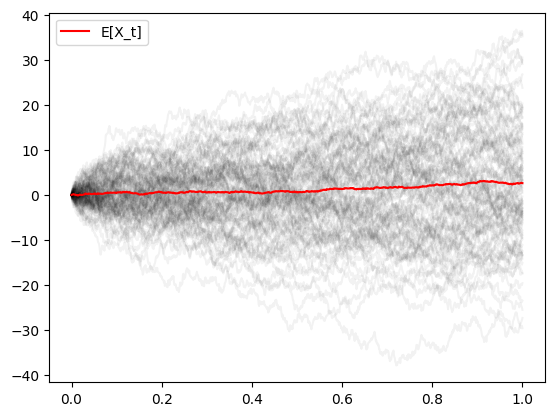

In [26]:
sgs.plot_paths()

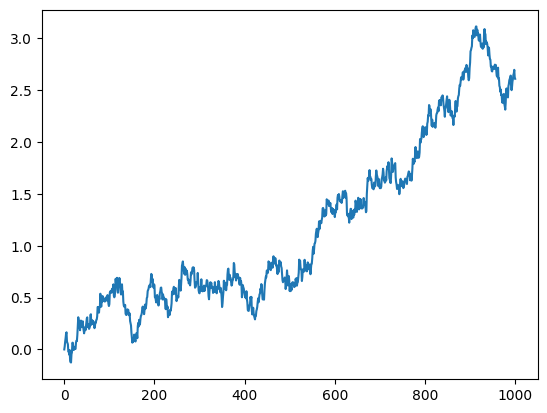

In [27]:
plt.plot(sgs.X_mat.mean(axis=1))

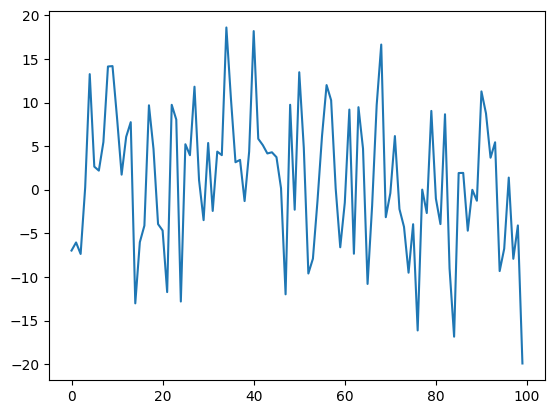

In [28]:
plt.plot(sgs.X_mat.mean(axis=0))

In [29]:
sgs.X_mat[:,0].mean(), sgs.X_mat[:,1].mean(), sgs.X_mat[:,2].mean()

(np.float64(-6.9726575918811236),
 np.float64(-6.043321336711528),
 np.float64(-7.362159699708151))

In [30]:
sgs.X_mat[0,:].mean(), sgs.X_mat[1,:].mean(), sgs.X_mat[2,:].mean()

(np.float64(0.0),
 np.float64(0.029700420937865037),
 np.float64(0.07663613290178334))

In [58]:
X, Y = np.meshgrid(m_h_vec, alpha_h_vec)
Z = home_optimal_control(hbar=HBAR, m_h=X, alpha_h=Y, beta_h=BETA_H)

In [37]:
Z.shape

(100, 100)

Text(0, 0.5, 'alpha_h')

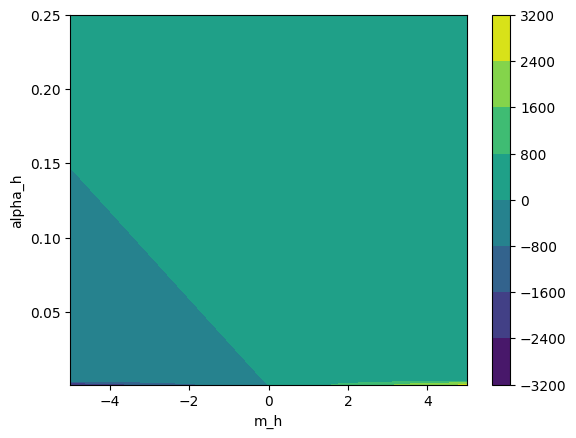

In [59]:
plt.contourf(X,Y,Z)
plt.colorbar()
plt.xlabel('m_h')
plt.ylabel('alpha_h')

Text(0.5, 0.92, 'Surface Plot')

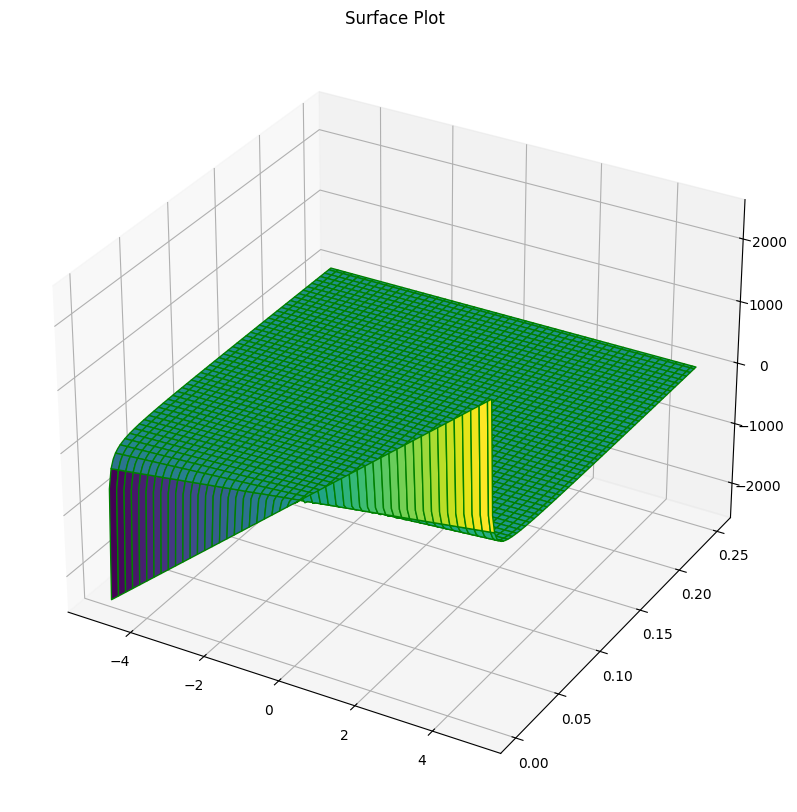

In [64]:
fig = plt.figure(figsize=(20,10))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='green')
ax.set_title('Surface Plot')